# Build a model

Are the signals from `pbs-1`, `pbs-2`, and `pbs-3` sufficiently discrimatory of human breast cancer?


## 0. Initializations

In [1]:
## 0. Initializations
# -- imports --
import anndata as ad
import gseapy as gp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import seaborn as sns

import random

from collections import defaultdict

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.metrics import classification_report

from statistics import median

from sklearn.svm import LinearSVC

from signals_in_the_noise.analysis.noise_phenotypes import classify_noise_subtypes
from signals_in_the_noise.preprocessing.gse161529 import GSE161529

In [2]:
# -- datasets --
gse = GSE161529()

## 1. Preprocessing Data

1. Subset data to samples that have a potential biological signal.
2. Determine the distribution of number of samples per subject - use to downsample for parity.
3. Determine the distribution of number of cells per subject - use to downsample for parity

In [3]:
from signals_in_the_noise.analysis.noise_phenotypes import PbsThresholds, Thresholds

pbs_1_thresholds = PbsThresholds(
    pct_counts_mt=Thresholds(q_low=0.85, q_high=None, q_mod_low=None, q_mod_high=None),
    log1p_total_counts=Thresholds(q_low=None, q_high=0.3, q_mod_low=None, q_mod_high=None),
    log1p_n_genes_by_counts=Thresholds(q_low=None, q_high=0.3, q_mod_low=None, q_mod_high=None),
)
pbs_2_thresholds = PbsThresholds(
    pct_counts_mt=Thresholds(q_low=None, q_high=0.25, q_mod_low=None, q_mod_high=None),
    log1p_total_counts=Thresholds(q_low=None, q_high=0.3, q_mod_low=None, q_mod_high=None),
    log1p_n_genes_by_counts=Thresholds(q_low=None, q_high=None, q_mod_low=0.45, q_mod_high=0.85),
)
pbs_3_thresholds = PbsThresholds(
    pct_counts_mt=Thresholds(q_low=None, q_high=None, q_mod_low=0.3, q_mod_high=0.65),
    log1p_total_counts=Thresholds(q_low=None, q_high=None, q_mod_low=0.5, q_mod_high=0.85),
    log1p_n_genes_by_counts=Thresholds(q_low=0.95, q_high=None, q_mod_low=None, q_mod_high=None),
)
# pbs_1_thresholds = PbsThresholds(
#     pct_counts_mt=Thresholds(q_low=0.9, q_high=None, q_mod_low=None, q_mod_high=None),
#     log1p_total_counts=Thresholds(q_low=None, q_high=None, q_mod_low=0.1, q_mod_high=0.25),
#     log1p_n_genes_by_counts=Thresholds(q_low=None, q_high=0.25, q_mod_low=None, q_mod_high=None),
# )
# pbs_2_thresholds = PbsThresholds(
#     pct_counts_mt=Thresholds(q_low=None, q_high=0.15, q_mod_low=None, q_mod_high=None),
#     log1p_total_counts=Thresholds(q_low=None, q_high=None, q_mod_low=0.1, q_mod_high=0.25),
#     log1p_n_genes_by_counts=Thresholds(q_low=None, q_high=None, q_mod_low=0.40, q_mod_high=0.65),
# )
# pbs_3_thresholds = PbsThresholds(
#     pct_counts_mt=Thresholds(q_low=None, q_high=None, q_mod_low=0.25, q_mod_high=0.55),
#     log1p_total_counts=Thresholds(q_low=0.45, q_high=None, q_mod_low=None, q_mod_high=None),
#     log1p_n_genes_by_counts=Thresholds(q_low=0.7, q_high=None, q_mod_low=None, q_mod_high=None),
# )

In [4]:
# -- subset data --
subtype_to_adata = defaultdict(dict)
choices = ["pbs-1", "pbs-2", "pbs-3"]
for adata in gse.objects.values():
    if adata.uns['cell_population'] != 'Total':
        continue
    adata_noise = adata[adata.obs["is_noise"] == 1].copy()
    classify_noise_subtypes(adata_noise, pbs_thresholds={
        "pbs-1": pbs_1_thresholds,
        "pbs-2": pbs_2_thresholds,
        "pbs-3": pbs_3_thresholds,
})
#     classify_noise_subtypes(adata_noise)
    conditions = [
        adata_noise.obs["pbs-1"] == 1,
        adata_noise.obs["pbs-2"] == 1,
        adata_noise.obs["pbs-3"] == 1,
    ]
    adata_noise.obs["pbs"] = np.select(conditions, choices, default="none")
    adata_pbs_only = adata_noise[adata_noise.obs["pbs"] != "none"]
    subtype_to_adata[adata_pbs_only.uns['cancer_type']].update({
        adata_pbs_only.uns['title'] : adata_pbs_only
    })

In [5]:
subtype_to_adata.keys()

dict_keys(['Normal', 'BRCA1 pre-neoplastic', 'Triple negative tumour', 'Triple negative BRCA1 tumour', 'HER2+ tumour', 'PR+ tumour', 'ER+ tumour'])

In [6]:
def print_data_stats(adata_collection):
    results = []
    for subtype, adatas in adata_collection.items():
        num_subjects = len(adatas)
        num_samples = [adata.n_obs for adata in adatas.values()]
        print(f"{subtype} - {num_samples}")
        results.append((subtype, num_subjects, min(num_samples), median(num_samples)))
    
    return pd.DataFrame(results, columns=['Cancer sub-type', '# Subjects', 'Min # Samples', 'Median # Samples'])

print_data_stats(subtype_to_adata)

Normal - [40, 125, 565, 16, 28, 50, 6, 59, 58, 49, 37, 65, 178]
BRCA1 pre-neoplastic - [65, 54, 88, 84]
Triple negative tumour - [37, 68, 22, 72]
Triple negative BRCA1 tumour - [45, 96, 40, 136]
HER2+ tumour - [52, 205, 48, 4, 29, 593]
PR+ tumour - [21]
ER+ tumour - [143, 134, 144, 83, 21, 57, 152, 46, 36, 59, 66, 82, 100, 7, 261, 30, 462, 18]


,Cancer sub-type,# Subjects,Min # Samples,Median # Samples
0,Normal,13,6,50.0
1,BRCA1 pre-neoplastic,4,54,74.5
2,Triple negative tumour,4,22,52.5
3,Triple negative BRCA1 tumour,4,40,70.5
4,HER2+ tumour,6,4,50.0
5,PR+ tumour,1,21,21.0
6,ER+ tumour,18,7,74.0


### 1.a. Decisions

1. Exclude cancer sub-type `PR+ tumour` because there is only a single subject in the dataset.
2. Downsample subjects to `3` with a minimum of `50` samples.

### 1.b. Further subset data

Produces a dataset with the decisions.

In [7]:
def subset_data_for_modeling(require_min_subject=True, require_min_samples=True):
    results = {}
    for subtype, adatas in subtype_to_adata.items():
        if require_min_subject and subtype == 'PR+ tumour':
            # only has one subject, exclude
            continue
        valid_subjects_to_adata = defaultdict(dict)
        for adata in adatas.values():
            if require_min_samples and adata.n_obs < 50:
                # exclude subjects with fewer than 50 samples
                continue
            valid_subjects_to_adata.update({
                adata.uns['title']: adata,
            })
        results[subtype] = valid_subjects_to_adata
    return results
valid_adatas = subset_data_for_modeling()

In [8]:
print_data_stats(valid_adatas)

Normal - [125, 565, 50, 59, 58, 65, 178]
BRCA1 pre-neoplastic - [65, 54, 88, 84]
Triple negative tumour - [68, 72]
Triple negative BRCA1 tumour - [96, 136]
HER2+ tumour - [52, 205, 593]
ER+ tumour - [143, 134, 144, 83, 57, 152, 59, 66, 82, 100, 261, 462]


,Cancer sub-type,# Subjects,Min # Samples,Median # Samples
0,Normal,7,50,65.0
1,BRCA1 pre-neoplastic,4,54,74.5
2,Triple negative tumour,2,68,70.0
3,Triple negative BRCA1 tumour,2,96,116.0
4,HER2+ tumour,3,52,205.0
5,ER+ tumour,12,57,117.0


### 1.3. Utility to Generate Dataset for Modeling

Creates a list of dataframe from the AnnDatas that represents all cancer sub-types (except for `PR+ tumour`), with the following characteristics:

1. `3` subjects per sub-type, `6` sub-types = `18` total subjects
2. `1` dataframe per subject
3. Columns
   1. `has_cancer`
   2. `cancer_type`
   3. `cell_population`
   4. `menopause_status`
   5. `pbs-1`
   6. `pbs-2`
   7. `pbs-3`

Separating the subjects to a row will simplify using the leave-one-out strategy.

In [9]:
def generate_dataframe_for_modeling(adata, *, downsample=True):
    results = []
    for adatas in adata.values():
        if downsample:
            subjects = np.random.choice(list(adatas.keys()), 3)
        else:
            subjects = adatas.keys()

        for subject in subjects:
            adata = adatas[subject]
            df = pd.DataFrame({
                'pbs-1': adata.obs['pbs-1'].astype(int),
                'pbs-2': adata.obs['pbs-2'].astype(int),
                'pbs-3': adata.obs['pbs-3'].astype(int),
            })
            df['has_cancer'] = (adata.uns['cancer_type'] != 'Normal')
            df['cancer_type'] = str(adata.uns['cancer_type'])
            df['cell_population'] = str(adata.uns['cell_population'])
            df['menopause_status'] = str(adata.uns['menopause_status'])
            
            results.append(df)
    return results

In [10]:
# generate_dataframe_for_modeling(adata=valid_adatas)[0]

## 2. Build the classifier

In [11]:
def logistic_regression_loo_classifier(dfs, *, by_subjects=True, as_dict=False, model=None, target='cancer_type'):
    loo = LeaveOneOut()
    y_true, y_pred = [], []
    
    for train_idx, test_idx in loo.split(dfs):
        train_df = pd.concat([dfs[i] for i in train_idx])
        # there will only ever be one in the test
        test_df = dfs[test_idx[0]]
    
        X_train = train_df[['pbs-1', 'pbs-2', 'pbs-3']].values
        y_train = train_df[target].values
    
        X_test = test_df[['pbs-1', 'pbs-2', 'pbs-3']].values
        y_test = test_df[target].values

        if model is None:
            model = LogisticRegression(max_iter=1000)
        model.fit(X_train, y_train)
    
        if by_subjects:
            counts = np.unique(model.predict(X_test), return_counts=True)
            # return the majority vote for the subject
            y_pred.append(counts[0][np.argmax(counts[1])])
            y_true.append(test_df[target].iloc[0])
        else:
            y_pred.extend(model.predict(X_test))
            y_true.extend(y_test)
    
    return classification_report(y_true, y_pred, output_dict=as_dict)

### 2.1. Explore other models

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import BernoulliNB
import warnings
from sklearn.exceptions import UndefinedMetricWarning

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=43,
        C=10,   # default is 1
    ),
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced',
        random_state=43,
        max_depth=5,    # default is None
        min_samples_leaf=20,    # default is 1
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=31,    # was 3 in other nbs
        weights='uniform',  # was distance in other nbs
        metric='hamming',   # default is minkowski
    ),
    'Naive Bayes': BernoulliNB(),
    'Random Forest': RandomForestClassifier(
        max_depth=5,
        min_samples_leaf=20,
        class_weight='balanced',
        random_state=43,
    ),
    'Linear SVC': LinearSVC(
        random_state=43,
        class_weight='balanced',
        C=10,
    ),
    'Ridge Classifier': RidgeClassifier(
        random_state=43,
        class_weight='balanced',
        alpha=0.5,
    )
}

### 2.2. Model ANY cancer

#### 2.3.1 Need to downsample to proceed

The data is not balanced in several ways:
- Subjects skew to having cancer
- Sample count per subject varies

To address this, build several models for different views that are more balanced:
- Normal vs Abnormal
  - Abnormal can be any combination of cancer subjects. For example, group cancer by comparable subject count.
- Subset subjects to get a balanced 

In [13]:
dfs = generate_dataframe_for_modeling(adata=valid_adatas, downsample=False)

In [14]:
dfs_cancer = []
dfs_normal = []

for df in dfs:
    if df['cancer_type'].unique()[0] == 'Normal':
        dfs_normal.append(df)
    else:
        dfs_cancer.append(df)

In [15]:
def get_balanced_dataset(minority_dfs, majority_dfs, num_minority_subjects=6):
    # select the normal subjects first, its the smaller number of total subjects
    some_minority = random.sample(minority_dfs, k=min(num_minority_subjects, len(minority_dfs)))
    # total number of cells (samples) to use for downsampling the abnormal (cancer) subjects
    num_minority_cells = sum([df.count().unique()[0] for df in some_minority])

    majority_pool = majority_dfs.copy()
    some_majority = []
    num_majority_cells = 0
    # iterate over cancer subjects
    for _ in majority_dfs:
        major = majority_pool.pop(random.randrange(len(majority_pool)))
        major_count = major.count().unique()[0]
        if major_count > num_minority_cells:
            continue
        some_majority.append(major)
        num_majority_cells += major_count
        if num_majority_cells >= num_minority_cells:
            break

    # print(num_majority_cells, num_minority_cells)
    return some_minority, some_majority
    
balanced_dfs_normal, balanced_dfs_cancer = get_balanced_dataset(dfs_normal, dfs_cancer)   

In [16]:
def report_has_cancer(minority, majority):
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
        n_runs = 100
        model_avg_report = {}
        for model_name, model in models.items():
            reports = []
            for run in range(n_runs):
                _balanced_dfs_normal, _dfs = get_balanced_dataset(minority, majority)
                _dfs.extend(_balanced_dfs_normal)
                
                report = logistic_regression_loo_classifier(_dfs, by_subjects=False, as_dict=True, model=model, target="has_cancer")
                reports.append(pd.DataFrame(report).T)
        
            _avg_report = pd.concat(reports).groupby(level=0).mean()
        
            print(f"{'='*25}")
            print(f"Model: {model_name}")
            print(f"{'-'*25}")
            print(f"Mean: {_avg_report}")
            print()
            model_avg_report[model_name] = _avg_report
        return model_avg_report

report_has_cancer(dfs_normal, dfs_cancer)

Model: Logistic Regression
-------------------------
Mean:               precision    recall  f1-score     support
False          0.699142  0.609270  0.649692   934.16000
True           0.691919  0.767735  0.727072  1067.30000
accuracy       0.694540  0.694540  0.694540     0.69454
macro avg      0.695530  0.688502  0.688382  2001.46000
weighted avg   0.696948  0.694540  0.692169  2001.46000

Model: Decision Tree
-------------------------
Mean:               precision    recall  f1-score      support
False          0.704268  0.610442  0.652611   955.370000
True           0.691094  0.770485  0.727892  1092.380000
accuracy       0.695867  0.695867  0.695867     0.695867
macro avg      0.697681  0.690463  0.690251  2047.750000
weighted avg   0.698403  0.695867  0.693370  2047.750000

Model: KNN
-------------------------
Mean:               precision    recall  f1-score      support
False          0.000000  0.000000  0.000000   945.350000
True           0.536623  0.998552  0.697434  1106.3

{'Logistic Regression':               precision    recall  f1-score     support
 False          0.699142  0.609270  0.649692   934.16000
 True           0.691919  0.767735  0.727072  1067.30000
 accuracy       0.694540  0.694540  0.694540     0.69454
 macro avg      0.695530  0.688502  0.688382  2001.46000
 weighted avg   0.696948  0.694540  0.692169  2001.46000,
 'Decision Tree':               precision    recall  f1-score      support
 False          0.704268  0.610442  0.652611   955.370000
 True           0.691094  0.770485  0.727892  1092.380000
 accuracy       0.695867  0.695867  0.695867     0.695867
 macro avg      0.697681  0.690463  0.690251  2047.750000
 weighted avg   0.698403  0.695867  0.693370  2047.750000,
 'KNN':               precision    recall  f1-score      support
 False          0.000000  0.000000  0.000000   945.350000
 True           0.536623  0.998552  0.697434  1106.340000
 accuracy       0.536232  0.536232  0.536232     0.536232
 macro avg      0.268311  0.4

In [17]:
def report_cancer_sub_types(minority, majority):
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
        n_runs = 100
        model_avg_report = {}
        for model_name, model in models.items():
            reports = []
            for run in range(n_runs):
                _balanced_dfs_normal, _dfs = get_balanced_dataset(minority, majority)
                _dfs.extend(_balanced_dfs_normal)
                
                report = logistic_regression_loo_classifier(_dfs, by_subjects=False, as_dict=True, model=model)
                reports.append(pd.DataFrame(report).T)
        
            _avg_report = pd.concat(reports).groupby(level=0).mean()
        
            print(f"{'='*25}")
            print(f"Model: {model_name}")
            print(f"{'-'*25}")
            print(f"Mean: {_avg_report}")
            print()
            model_avg_report[model_name] = _avg_report
        return model_avg_report

# report_cancer_sub_types(dfs_normal, dfs_cancer)

In [18]:
targets = ['ER+ tumour',]
dfs_target_cancer = [df for df in dfs_cancer if df['cancer_type'].unique()[0] in targets]
avg_reports = report_cancer_sub_types(dfs_normal, dfs_target_cancer)

Model: Logistic Regression
-------------------------
Mean:               precision    recall  f1-score      support
ER+ tumour     0.710468  0.845035  0.771525  1082.000000
Normal         0.778437  0.612410  0.684729   957.200000
accuracy       0.735602  0.735602  0.735602     0.735602
macro avg      0.744452  0.728722  0.728127  2039.200000
weighted avg   0.743423  0.735602  0.731179  2039.200000

Model: Decision Tree
-------------------------
Mean:               precision    recall  f1-score      support
ER+ tumour     0.710874  0.843498  0.771168  1081.230000
Normal         0.774835  0.610952  0.682512   953.090000
accuracy       0.734775  0.734775  0.734775     0.734775
macro avg      0.742854  0.727225  0.726840  2034.320000
weighted avg   0.742037  0.734775  0.730350  2034.320000

Model: KNN
-------------------------
Mean:               precision    recall  f1-score      support
ER+ tumour     0.531462  1.000000  0.693540  1049.770000
Normal         0.000000  0.000000  0.000000  

In [19]:
# targets = ['HER2+ tumour', 'Triple negative tumour', 'Triple negative BRCA1 tumour']
# dfs_target_cancer = [df for df in dfs_cancer if df['cancer_type'].unique()[0] in targets]
# report_has_cancer(dfs_target_cancer, dfs_normal)

In [20]:
# targets = ['Triple negative tumour', 'Triple negative BRCA1 tumour']
# dfs_target_cancer = [df for df in dfs_cancer if df['cancer_type'].unique()[0] in targets]
# report_has_cancer(dfs_target_cancer, dfs_normal)

In [21]:
# targets = ['HER2+ tumour']
# dfs_target_cancer = [df for df in dfs_cancer if df['cancer_type'].unique()[0] in targets]
# report_has_cancer(dfs_target_cancer, dfs_normal)

In [22]:
# targets = ['BRCA1 pre-neoplastic']
# dfs_target_cancer = [df for df in dfs_cancer if df['cancer_type'].unique()[0] in targets]
# report_has_cancer(dfs_target_cancer, dfs_normal)

In [23]:
def figure_for_poster(avg_report, minority_label="True", majority_label="False", small=False):
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    import numpy as np
    
    # ── DATA from avg_report ─────────────────────────────────────────────────────
    support_false   = avg_report.loc[majority_label,     "support"]
    support_true    = avg_report.loc[minority_label,      "support"]
    recall_false    = avg_report.loc[majority_label,     "recall"]
    recall_true     = avg_report.loc[minority_label,      "recall"]
    precision_false = avg_report.loc[majority_label,     "precision"]
    precision_true  = avg_report.loc[minority_label,      "precision"]
    f1_false        = avg_report.loc[majority_label,     "f1-score"]
    f1_true         = avg_report.loc[minority_label,      "f1-score"]
    accuracy        = avg_report.loc["accuracy",  "f1-score"]
    macro_f1        = avg_report.loc["macro avg", "f1-score"]
    
    tn = round(support_false * recall_false)
    fp = round(support_false * (1 - recall_false))
    fn = round(support_true  * (1 - recall_true))
    tp = round(support_true  * recall_true)
    
    cm      = np.array([[tn, fp], [fn, tp]])
    support = [support_false, support_true]
    blue    = "#0072B2"
    orange  = "#D55E00"
    
    # ── FIGURE ───────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(8, 5))
    
    ax_cm     = fig.add_axes([0.05, 0.10, 0.50, 0.80])

    if small:
        font_sizes = [26, 20, 20]
    else:
        font_sizes = [32, 26, 20]
    
    # ── CONFUSION MATRIX ─────────────────────────────────────────────────────────
    if small:
        classes = [f"{minority_label}", f"{majority_label}"]
    else:
        classes = [f"{minority_label}\n(no cancer)", f"{majority_label}\n(cancer)"]
    
    for i in range(2):
        for j in range(2):
            val = cm[i, j]
            pct = val / support[i] if support[i] > 0 else 0
     
            if i == j:
                color = blue
                alpha = 0.15 + pct * 0.75
            else:
                color = orange
                alpha = 0.10 + pct * 0.70

            if small:
                rect = patches.FancyBboxPatch(
                    (j + 0.08, 1 - i + 0.08), 0.84, 0.84,
                    boxstyle="round,pad=0.02",
                    facecolor=color, alpha=max(alpha, 0.08),
                    linewidth=0
                )
            else:
                rect = patches.FancyBboxPatch(
                    (j + 0.04, 1 - i + 0.04), 0.92, 0.92,
                    boxstyle="round,pad=0.02",
                    facecolor=color, alpha=max(alpha, 0.08),
                    linewidth=0
                )
            ax_cm.add_patch(rect)
     
            text_color = "#00274C"
            if small:
                ax_cm.text(j + 0.5, 1 - i + 0.60, f"{int(val):,}",
                           ha="center", va="center",
                           fontsize=font_sizes[0], fontweight="500", color=text_color)
                ax_cm.text(j + 0.5, 1 - i + 0.35, f"{pct:.1%}",
                           ha="center", va="center",
                           fontsize=font_sizes[1], color=text_color, alpha=0.85)
            else:
                ax_cm.text(j + 0.5, 1 - i + 0.60, f"{int(val):,}",
                           ha="center", va="center",
                           fontsize=font_sizes[0], fontweight="500", color=text_color)
                ax_cm.text(j + 0.5, 1 - i + 0.28, f"{pct:.1%}",
                           ha="center", va="center",
                           fontsize=font_sizes[1], color=text_color, alpha=0.85)
     
    ax_cm.set_xticks([0.5, 1.5])
    ax_cm.set_xticklabels(classes, fontsize=font_sizes[2], color="#00274C")
    ax_cm.set_yticks([0.5, 1.5])
    ax_cm.set_yticklabels(classes[::-1], fontsize=font_sizes[2])
    ax_cm.set_xlim(0, 2)
    ax_cm.set_ylim(0, 2)
    ax_cm.set_xlabel("predicted label", fontsize=font_sizes[2])
    ax_cm.set_ylabel("true label", fontsize=font_sizes[2])
    ax_cm.spines[:].set_visible(False)
    ax_cm.tick_params(length=0)

    plt.rcParams.update({
        'axes.labelcolor': "#00274C",
        'text.color': "#00274C",
        'xtick.labelcolor': "#00274C",
        'ytick.labelcolor': "#00274C",
    })
    if small:
        plt.savefig("../images/iscb-scs-postcard.png", dpi=300, bbox_inches="tight", transparent=True)
    else:
        plt.savefig("../images/iscb-scs-figure-4.png", dpi=300, bbox_inches="tight", transparent=True)
    plt.show()

In [24]:
avg_report = avg_reports['Random Forest']

In [25]:
avg_report

,precision,recall,f1-score,support
ER+ tumour,0.706539,0.837244,0.766025,1062.9100
Normal,0.774455,0.615565,0.685311,959.3500
accuracy,0.732100,0.732100,0.732100,0.7321
macro avg,0.740497,0.726404,0.725668,2022.2600
weighted avg,0.739548,0.732100,0.728137,2022.2600


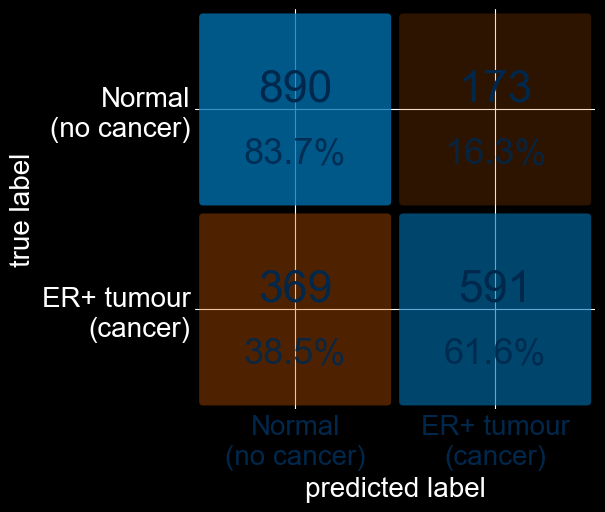

In [26]:
figure_for_poster(avg_report, "Normal", "ER+ tumour")

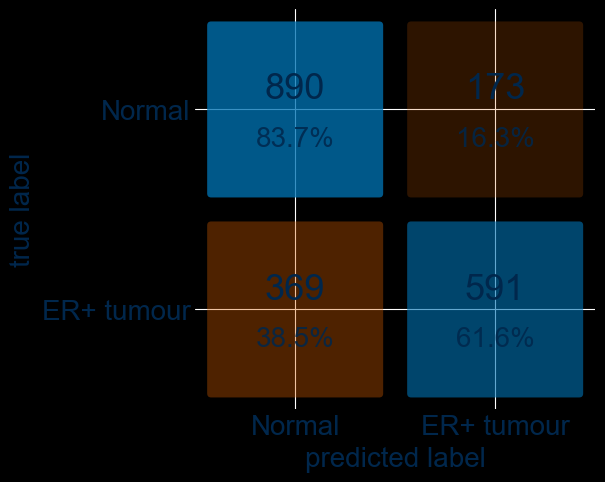

In [27]:
figure_for_poster(avg_report, "Normal", "ER+ tumour", small=True)